# Formula 1 Tyre Degradation Analysis
This project uses historical Formula 1 race data to analyse driver pace and tyre degradation. The aim is to investigate how tyre performance changes throughout a stint and estimate the relationship between tyre age and lap time.

In [1]:
%pip install -q fastf1

Note: you may need to restart the kernel to use updated packages.


In [2]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


fastf1.set_log_level("WARNING")

compound_colours = {
    "SOFT": "red",
    "MEDIUM": "gold",
    "HARD": "white",
    "INTERMEDIATE": "green",
    "WET": "blue"
}

## 1. Initial Exploration - British Grand Prix

In [3]:
year = 2025
grand_prix = "British Grand Prix"
session = fastf1.get_session(year, grand_prix, "R")
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (223.96 MB) /Users/shveta/Library/Caches/fastf1
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 43)


In [4]:
laps = session.laps
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:57:55.042000,VER,1,0 days 00:01:45.820000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:41.707000,...,True,Red Bull Racing,0 days 00:56:09.003000,2025-07-06 14:03:49.616,12,1.0,False,,False,False
1,0 days 01:00:10.640000,VER,1,0 days 00:02:15.598000,2.0,1.0,NaT,NaT,0 days 00:00:45.755000,0 days 00:00:53.700000,...,True,Red Bull Racing,0 days 00:57:55.042000,2025-07-06 14:05:35.655,26,1.0,False,,False,False
2,0 days 01:02:27.997000,VER,1,0 days 00:02:17.357000,3.0,1.0,NaT,NaT,0 days 00:00:48.885000,0 days 00:00:50.924000,...,True,Red Bull Racing,0 days 01:00:10.640000,2025-07-06 14:07:51.253,6,1.0,False,,False,False
3,0 days 01:04:13.565000,VER,1,0 days 00:01:45.568000,4.0,1.0,NaT,NaT,0 days 00:00:36.223000,0 days 00:00:40.712000,...,True,Red Bull Racing,0 days 01:02:27.997000,2025-07-06 14:10:08.610,6712,1.0,False,,False,False
4,0 days 01:05:58.374000,VER,1,0 days 00:01:44.809000,5.0,1.0,NaT,NaT,0 days 00:00:31.996000,0 days 00:00:43.110000,...,True,Red Bull Racing,0 days 01:04:13.565000,2025-07-06 14:11:54.178,126,1.0,False,,False,False


In [5]:
norris_laps = laps.pick_drivers("NOR")
norris_laps[["LapNumber", "LapTime", "Compound", "TyreLife"]].head(10)

,LapNumber,LapTime,Compound,TyreLife
491,1.0,0 days 00:01:48.196000,INTERMEDIATE,1.0
492,2.0,0 days 00:02:16.245000,INTERMEDIATE,2.0
493,3.0,0 days 00:02:17.443000,INTERMEDIATE,3.0
494,4.0,0 days 00:01:45.751000,INTERMEDIATE,4.0
495,5.0,0 days 00:01:45.033000,INTERMEDIATE,5.0
496,6.0,0 days 00:02:19.233000,INTERMEDIATE,6.0
497,7.0,0 days 00:02:03.224000,INTERMEDIATE,7.0
498,8.0,0 days 00:01:44.869000,INTERMEDIATE,8.0
499,9.0,0 days 00:01:45.595000,INTERMEDIATE,9.0
500,10.0,0 days 00:01:45.857000,INTERMEDIATE,10.0


In [6]:
norris_laps = norris_laps.copy()
norris_laps["LapTimeSeconds"] = norris_laps["LapTime"].dt.total_seconds()
norris_laps[["LapNumber", "LapTime", "LapTimeSeconds"]].head(10)

,LapNumber,LapTime,LapTimeSeconds
491,1.0,0 days 00:01:48.196000,108.196
492,2.0,0 days 00:02:16.245000,136.245
493,3.0,0 days 00:02:17.443000,137.443
494,4.0,0 days 00:01:45.751000,105.751
495,5.0,0 days 00:01:45.033000,105.033
496,6.0,0 days 00:02:19.233000,139.233
497,7.0,0 days 00:02:03.224000,123.224
498,8.0,0 days 00:01:44.869000,104.869
499,9.0,0 days 00:01:45.595000,105.595
500,10.0,0 days 00:01:45.857000,105.857


In [7]:
norris_laps.groupby("Stint").agg(
    StartLap=("LapNumber", "min"),
    EndLap=("LapNumber", "max"), 
    Compound=("Compound", "first"),
    StartTyreLife=("TyreLife", "min"),
    EndTyreLife=("TyreLife", "max")
)

,StartLap,EndLap,Compound,StartTyreLife,EndTyreLife
Stint,,,,,
1.0,1.0,11.0,INTERMEDIATE,1.0,11.0
2.0,12.0,44.0,INTERMEDIATE,1.0,33.0
3.0,45.0,52.0,MEDIUM,1.0,8.0


In [8]:
norris_laps[
    ["LapNumber", "LapTimeSeconds", "Compound", "Stint", "IsAccurate"]
].head(20)

,LapNumber,LapTimeSeconds,Compound,Stint,IsAccurate
491,1.0,108.196,INTERMEDIATE,1.0,False
492,2.0,136.245,INTERMEDIATE,1.0,False
493,3.0,137.443,INTERMEDIATE,1.0,False
494,4.0,105.751,INTERMEDIATE,1.0,False
495,5.0,105.033,INTERMEDIATE,1.0,False
496,6.0,139.233,INTERMEDIATE,1.0,False
497,7.0,123.224,INTERMEDIATE,1.0,False
498,8.0,104.869,INTERMEDIATE,1.0,True
499,9.0,105.595,INTERMEDIATE,1.0,True
500,10.0,105.857,INTERMEDIATE,1.0,True


In [9]:
clean_laps = norris_laps[
    norris_laps["IsAccurate"] == True
].copy()

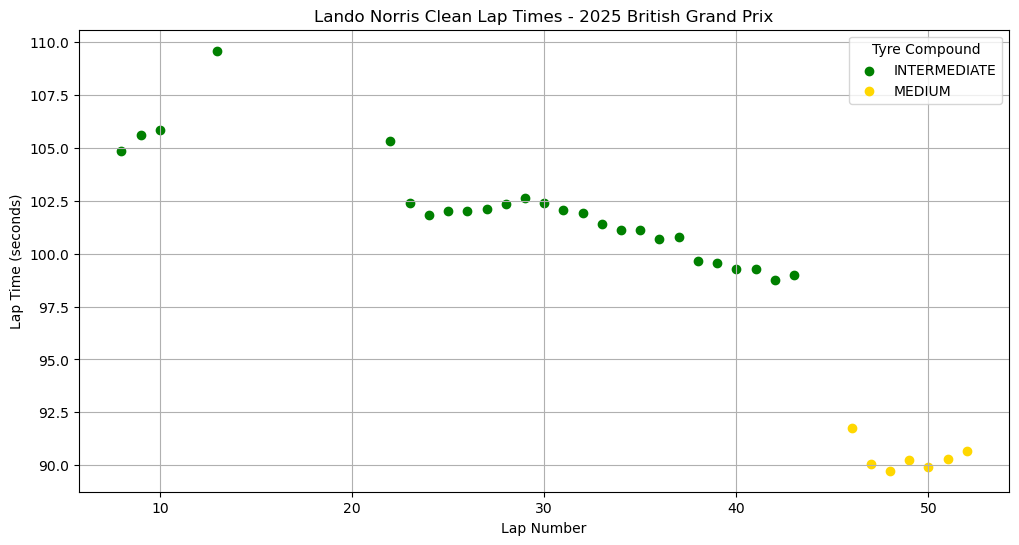

In [10]:
plt.figure(figsize=(12, 6))

for compound in clean_laps["Compound"].dropna().unique():
    
    compound_laps = clean_laps[clean_laps["Compound"] == compound]
    
    plt.scatter(
        compound_laps["LapNumber"],
        compound_laps["LapTimeSeconds"],
        label=compound,
        color=compound_colours[compound]
    )

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Lando Norris Clean Lap Times - 2025 British Grand Prix")

plt.legend(title="Tyre Compound")
plt.grid(True)

plt.show()

I initially explored Lando Norris's lap data from the 2025 British Grand Prix. However, changing weather conditions meant that lap times were strongly affected by track conditions and tyre type. I therefore selected the dry Japanese Grand Prix for the main tyre degradation analysis.

## 2. Main Analysis - Japanese Grand Prix

In [11]:
year = 2025
grand_prix = "Japanese Grand Prix"
japan = fastf1.get_session(year, grand_prix, "R")
japan.load()

In [12]:
japan_laps = japan.laps

japan_laps[
    ["Driver", "LapNumber", "LapTime", "Compound", "TyreLife", "Stint"]
].head(10)

,Driver,LapNumber,LapTime,Compound,TyreLife,Stint
0,VER,1.0,0 days 00:01:34.725000,MEDIUM,1.0,1.0
1,VER,2.0,0 days 00:01:33.943000,MEDIUM,2.0,1.0
2,VER,3.0,0 days 00:01:33.639000,MEDIUM,3.0,1.0
3,VER,4.0,0 days 00:01:33.744000,MEDIUM,4.0,1.0
4,VER,5.0,0 days 00:01:33.776000,MEDIUM,5.0,1.0
5,VER,6.0,0 days 00:01:33.646000,MEDIUM,6.0,1.0
6,VER,7.0,0 days 00:01:33.526000,MEDIUM,7.0,1.0
7,VER,8.0,0 days 00:01:33.536000,MEDIUM,8.0,1.0
8,VER,9.0,0 days 00:01:33.529000,MEDIUM,9.0,1.0
9,VER,10.0,0 days 00:01:33.555000,MEDIUM,10.0,1.0


In [13]:
japan.results[
    ["Abbreviation", "FullName", "TeamName", "Position"]
]

,Abbreviation,FullName,TeamName,Position
1,VER,Max Verstappen,Red Bull Racing,1.0
4,NOR,Lando Norris,McLaren,2.0
81,PIA,Oscar Piastri,McLaren,3.0
16,LEC,Charles Leclerc,Ferrari,4.0
63,RUS,George Russell,Mercedes,5.0
12,ANT,Kimi Antonelli,Mercedes,6.0
44,HAM,Lewis Hamilton,Ferrari,7.0
6,HAD,Isack Hadjar,Racing Bulls,8.0
23,ALB,Alexander Albon,Williams,9.0
87,BEA,Oliver Bearman,Haas F1 Team,10.0


In [14]:
driver_laps = japan_laps.pick_drivers("VER").copy()
driver_laps[["LapNumber", "LapTime", "Compound", "TyreLife"]].head(20)

,LapNumber,LapTime,Compound,TyreLife
0,1.0,0 days 00:01:34.725000,MEDIUM,1.0
1,2.0,0 days 00:01:33.943000,MEDIUM,2.0
2,3.0,0 days 00:01:33.639000,MEDIUM,3.0
3,4.0,0 days 00:01:33.744000,MEDIUM,4.0
4,5.0,0 days 00:01:33.776000,MEDIUM,5.0
5,6.0,0 days 00:01:33.646000,MEDIUM,6.0
6,7.0,0 days 00:01:33.526000,MEDIUM,7.0
7,8.0,0 days 00:01:33.536000,MEDIUM,8.0
8,9.0,0 days 00:01:33.529000,MEDIUM,9.0
9,10.0,0 days 00:01:33.555000,MEDIUM,10.0


In [15]:
driver_laps.groupby("Stint").agg(
    StartLap=("LapNumber", "min"),
    EndLap=("LapNumber", "max"), 
    Compound=("Compound", "first"),
    StartTyreLife=("TyreLife", "min"),
    EndTyreLife=("TyreLife", "max")
)

,StartLap,EndLap,Compound,StartTyreLife,EndTyreLife
Stint,,,,,
1.0,1.0,21.0,MEDIUM,1.0,21.0
2.0,22.0,53.0,HARD,1.0,32.0


## 3. Initial Tyre Degradation Model

To establish a baseline model, I first analysed Verstappen's opening medium-tyre stint. A simple linear regression was fitted between tyre age and lap time.

In [16]:
driver_laps[
    ["LapNumber", "LapTime", "Compound", "Stint", "IsAccurate"]
].head(20)

,LapNumber,LapTime,Compound,Stint,IsAccurate
0,1.0,0 days 00:01:34.725000,MEDIUM,1.0,False
1,2.0,0 days 00:01:33.943000,MEDIUM,1.0,True
2,3.0,0 days 00:01:33.639000,MEDIUM,1.0,True
3,4.0,0 days 00:01:33.744000,MEDIUM,1.0,True
4,5.0,0 days 00:01:33.776000,MEDIUM,1.0,True
5,6.0,0 days 00:01:33.646000,MEDIUM,1.0,True
6,7.0,0 days 00:01:33.526000,MEDIUM,1.0,True
7,8.0,0 days 00:01:33.536000,MEDIUM,1.0,True
8,9.0,0 days 00:01:33.529000,MEDIUM,1.0,True
9,10.0,0 days 00:01:33.555000,MEDIUM,1.0,True


In [17]:
driver_laps["LapTimeSeconds"] = driver_laps["LapTime"].dt.total_seconds()

stint1 = driver_laps[
    (driver_laps["Stint"] == 1) &
    (driver_laps["IsAccurate"] == True)
].copy()

stint1[["LapNumber", "TyreLife", "LapTimeSeconds", "Compound"]]

,LapNumber,TyreLife,LapTimeSeconds,Compound
1,2.0,2.0,93.943,MEDIUM
2,3.0,3.0,93.639,MEDIUM
3,4.0,4.0,93.744,MEDIUM
4,5.0,5.0,93.776,MEDIUM
5,6.0,6.0,93.646,MEDIUM
6,7.0,7.0,93.526,MEDIUM
7,8.0,8.0,93.536,MEDIUM
8,9.0,9.0,93.529,MEDIUM
9,10.0,10.0,93.555,MEDIUM
10,11.0,11.0,93.498,MEDIUM


In [18]:
x = stint1["TyreLife"]
y = stint1["LapTimeSeconds"]

slope, intercept = np.polyfit(x, y, 1)

print("Slope:", slope)
print("Intercept:", intercept)

Slope: -0.028359649122805145
Intercept: 93.84727192982453


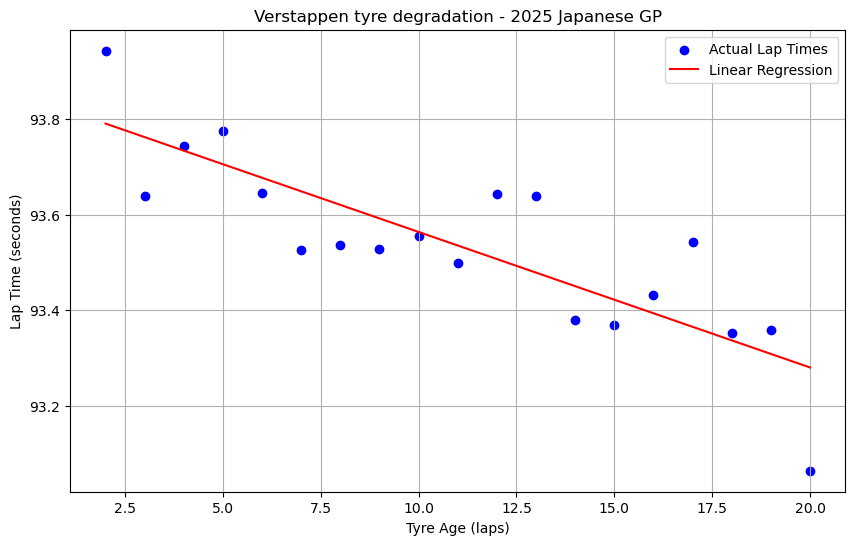

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(x, y, color="blue", label="Actual Lap Times")
plt.plot(
    x, 
    slope * x + intercept, 
    color="red",
    label="Linear Regression"
)

plt.xlabel("Tyre Age (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Verstappen tyre degradation - 2025 Japanese GP")

plt.legend()
plt.grid(True)
plt.show()

In [20]:
predicted_lap_times = slope * x + intercept

ss_res = np.sum((y - predicted_lap_times) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

r_squared = 1 - (ss_res / ss_tot)

print("Slope:", round(slope, 4))
print("Intercept:", round(intercept, 4))
print("R^2:", round(r_squared, 4))

Slope: -0.0284
Intercept: 93.8473
R^2: 0.6894


A linear regression was fitted between tyre age and lap time for Verstappen's first stint.

The model produced a slope of -0.0284 seconds per lap with an R^2 value of 0.6894.

The negative coefficient suggests that lap times became faster as tyre age increased. However, this should not be interpreted as negative tyre degradation. During a race, fuel is continuously burned, reducing the mass of the car and generally improving lap time.

Therefore, tyre age is correlated with other variables that affect lap time. A more sophisticated model is required to separate tyre degradation from race progression and other effects.

## 4. Full Race Pace Analysis

To analyse Verstappen's pace across both tyre stints, laps with missing lap times and pit-in/pit-out laps were removed. Pit laps are not representative of normal racing pace and would otherwise introduce large outliers into the analysis.

In [21]:
clean_laps = driver_laps.copy()

clean_laps["LapTimeSeconds"] = (
    clean_laps["LapTime"].dt.total_seconds()
)

clean_laps = clean_laps.dropna(subset=["LapTimeSeconds"])

clean_laps = clean_laps[
    clean_laps["PitInTime"].isna() &
    clean_laps["PitOutTime"].isna()
].copy()

clean_laps[
    ["LapNumber", "LapTimeSeconds", "Compound", "TyreLife", "Stint"]
]

,LapNumber,LapTimeSeconds,Compound,TyreLife,Stint
0,1.0,94.725,MEDIUM,1.0,1.0
1,2.0,93.943,MEDIUM,2.0,1.0
2,3.0,93.639,MEDIUM,3.0,1.0
3,4.0,93.744,MEDIUM,4.0,1.0
4,5.0,93.776,MEDIUM,5.0,1.0
5,6.0,93.646,MEDIUM,6.0,1.0
6,7.0,93.526,MEDIUM,7.0,1.0
7,8.0,93.536,MEDIUM,8.0,1.0
8,9.0,93.529,MEDIUM,9.0,1.0
9,10.0,93.555,MEDIUM,10.0,1.0


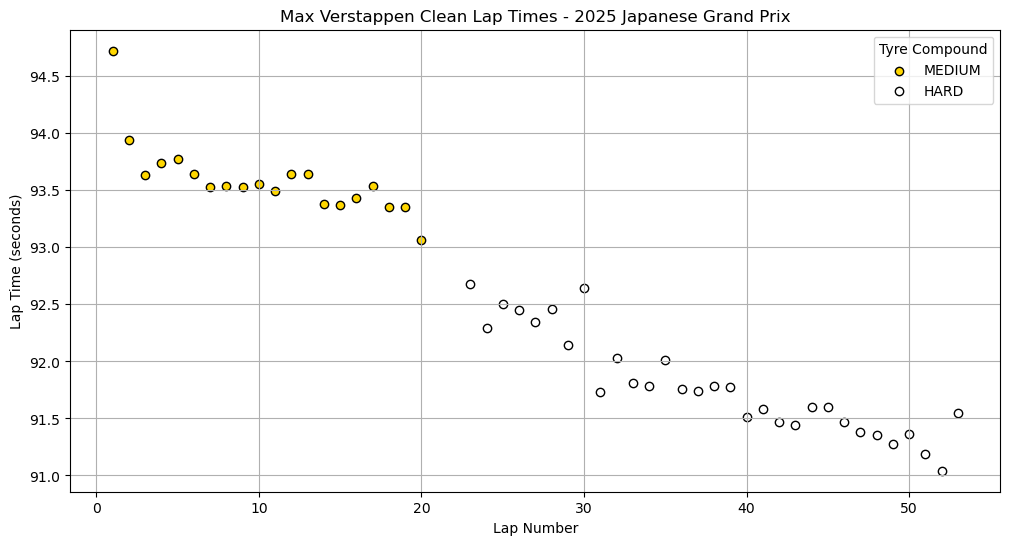

In [22]:
plt.figure(figsize=(12, 6))

compound_colours = {
    "SOFT": "red",
    "MEDIUM": "gold",
    "HARD": "white",
    "INTERMEDIATE": "green",
    "WET": "blue"
}

for compound in clean_laps["Compound"].dropna().unique():
    
    compound_laps = clean_laps[
        clean_laps["Compound"] == compound
    ]

    plt.scatter(
        compound_laps["LapNumber"],
        compound_laps["LapTimeSeconds"],
        label=compound,
        color=compound_colours[compound],
        edgecolors="black"
    )

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Max Verstappen Clean Lap Times - 2025 Japanese Grand Prix")

plt.legend(title="Tyre Compound")
plt.grid(True)

plt.show()

## 5. Multiple Regression Model

The initial model only considered tyre age, despite lap time also changing as the race progressed. To better isolate the relationship between tyre age and lap time, a multiple
regression model was constructed using:
- TyreLife – age of the current tyre set
- LapNumber – a proxy for race progression and decreasing fuel load
- HardTyre – a binary variable controlling for tyre compound

In [23]:
clean_laps["HardTyre"] = (
    clean_laps["Compound"] == "HARD"
).astype(int)

X = clean_laps[
    ["TyreLife", "LapNumber", "HardTyre"]
].to_numpy()

X = np.column_stack((np.ones(len(X)), X))

y_multi = clean_laps["LapTimeSeconds"].to_numpy()

coefficients = np.linalg.lstsq(X, y_multi, rcond=None)[0]

intercept_multi = coefficients[0]
tyre_age_coefficient = coefficients[1]
lap_number_coefficient = coefficients[2]
hard_tyre_coefficient = coefficients[3]

print("Intercept:", round(intercept_multi, 4))
print("Tyre age coefficient:", round(tyre_age_coefficient, 4))
print("Lap number coefficient:", round(lap_number_coefficient, 4))
print("Hard tyre coefficient:", round(hard_tyre_coefficient, 4))

Intercept: 94.0613
Tyre age coefficient: 0.0271
Lap number coefficient: -0.0715
Hard tyre coefficient: -0.0047


## 6. Results and Conclusion

The initial simple regression produced a tyre-age coefficient of -0.0284 seconds per lap, suggesting that lap times became faster as the tyres aged. This was likely because tyre age was confounded with race progression.

To improve the model, I included tyre age, race lap number and tyre compound as explanatory variables.

The multiple regression produced:

- Tyre age: +0.0271 seconds per lap
- Race lap: -0.0715 seconds per lap
- Hard tyre: -0.0047 seconds
- Intercept: 94.0613 seconds

After accounting for race progression and tyre compound, the tyre-age coefficient became positive. The model therefore estimates that an additional lap of tyre age is associated with approximately 0.027 seconds of increased lap time.

The negative race-lap coefficient suggests that overall lap times tend to decrease as the race progresses. This may partly reflect decreasing fuel load, although race lap is only a proxy and may also capture factors such as track evolution.

These results demonstrate why controlling for confounding variables is important when estimating tyre degradation from race data.